In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense,
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dropout,
    BatchNormalization
)

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ReduceLROnPlateau

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

print("All libraries imported successfully!")
print("TensorFlow Version:", tf.__version__)

All libraries imported successfully!
TensorFlow Version: 2.21.0


In [2]:
labels = ['PNEUMONIA', 'NORMAL']
img_resize = 150

def get_data(directory):
    data = []

    for label in labels:
        path = os.path.join(directory, label)
        class_num = labels.index(label)

        if not os.path.exists(path):
            print(f"Folder not found: {path}")
            continue

        for img in os.listdir(path):
            try:
                if img.lower().endswith(('.jpeg', '.jpg', '.png')):
                    img_path = os.path.join(path, img)

                    img_arr = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

                    if img_arr is None:
                        continue

                    resized_arr = cv2.resize(img_arr, (img_resize, img_resize))
                    data.append([resized_arr, class_num])

            except Exception as e:
                print(f"Error loading {img}: {e}")

    return np.array(data, dtype=object)

In [3]:
train_path = "C:/Users/Dell/OneDrive/Desktop/Pneumonia_Detection/chest_xray/train"
test_path = "C:/Users/Dell/OneDrive/Desktop/Pneumonia_Detection/chest_xray/test"

In [5]:
train = get_data("C:/Users/Dell/OneDrive/Desktop/Pneumonia_Detection/chest_xray/train")
test = get_data("C:/Users/Dell/OneDrive/Desktop/Pneumonia_Detection/chest_xray/test")
val = get_data("C:/Users/Dell/OneDrive/Desktop/Pneumonia_Detection/chest_xray/val")

print("Training Images:", len(train))
print("Testing Images:", len(test))
print("Validation Images:", len(val))

Training Images: 5216
Testing Images: 624
Validation Images: 16


<Axes: xlabel='count'>

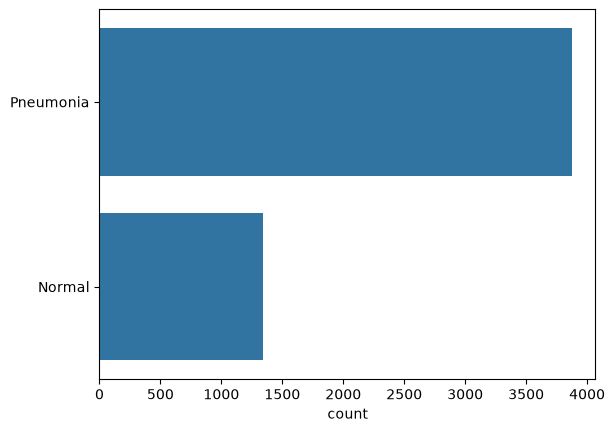

In [6]:
l = []
for i in train:
  if (i[1] == 0):
    l.append('Pneumonia')
  else:
    l.append('Normal')

sns.countplot(l)

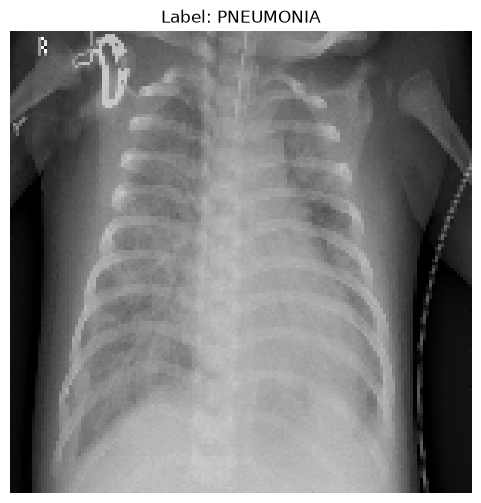

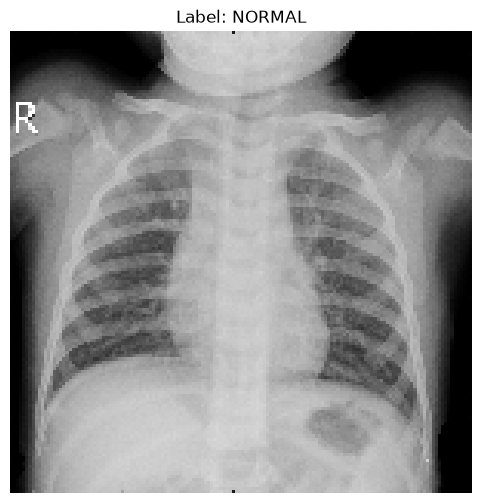

In [7]:
# ==========================================
# Step 4: Display Sample Images
# ==========================================

plt.figure(figsize=(6, 6))
plt.imshow(train[0][0], cmap='gray')
plt.title(f"Label: {labels[train[0][1]]}")
plt.axis('off')

plt.figure(figsize=(6, 6))
plt.imshow(train[-11][0], cmap='gray')
plt.title(f"Label: {labels[train[-11][1]]}")
plt.axis('off')

plt.show()

In [9]:
# ==========================================
# Step 5: Separate Images and Labels
# ==========================================

x_train = []
y_train = []

x_val = []
y_val = []

x_test = []
y_test = []

# Training Data
for image, label in train:
    x_train.append(image)
    y_train.append(label)

# Validation Data
for image, label in val:
    x_val.append(image)
    y_val.append(label)

# Testing Data
for image, label in test:
    x_test.append(image)
    y_test.append(label)

print("Training Images :", len(x_train))
print("Validation Images:", len(x_val))
print("Testing Images  :", len(x_test))

Training Images : 5216
Validation Images: 16
Testing Images  : 624


In [10]:
# ==========================================
# Step 6: Normalize Image Data
# ==========================================

x_train = np.array(x_train, dtype=np.float32) / 255.0
x_val = np.array(x_val, dtype=np.float32) / 255.0
x_test = np.array(x_test, dtype=np.float32) / 255.0

print("Training Data Shape :", x_train.shape)
print("Validation Data Shape:", x_val.shape)
print("Testing Data Shape  :", x_test.shape)

Training Data Shape : (5216, 150, 150)
Validation Data Shape: (16, 150, 150)
Testing Data Shape  : (624, 150, 150)


In [11]:
x_train

array([[[0.07058824, 0.10980392, 0.11372549, ..., 0.05098039,
         0.02745098, 0.00392157],
        [0.08235294, 0.09411765, 0.11372549, ..., 0.05490196,
         0.03529412, 0.01176471],
        [0.08627451, 0.10196079, 0.1254902 , ..., 0.0627451 ,
         0.03529412, 0.00784314],
        ...,
        [0.03921569, 0.03529412, 0.03137255, ..., 0.05882353,
         0.05882353, 0.05882353],
        [0.03921569, 0.03921569, 0.03137255, ..., 0.05882353,
         0.05882353, 0.05882353],
        [0.03921569, 0.03921569, 0.03137255, ..., 0.05882353,
         0.05882353, 0.05882353]],

       [[0.23921569, 0.27450982, 0.29803923, ..., 0.10980392,
         0.09803922, 0.08627451],
        [0.29411766, 0.31764707, 0.3137255 , ..., 0.10980392,
         0.09411765, 0.09019608],
        [0.3372549 , 0.3254902 , 0.33333334, ..., 0.12156863,
         0.09019608, 0.08235294],
        ...,
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0. 

In [12]:
# ==========================================
# Step 7: Reshape Images and Convert Labels
# ==========================================

# Reshape image data for CNN
x_train = x_train.reshape(-1, img_resize, img_resize, 1)
x_val = x_val.reshape(-1, img_resize, img_resize, 1)
x_test = x_test.reshape(-1, img_resize, img_resize, 1)

# Convert labels to NumPy arrays
y_train = np.array(y_train, dtype=np.int32)
y_val = np.array(y_val, dtype=np.int32)
y_test = np.array(y_test, dtype=np.int32)

# Display data shapes
print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)

print("x_val shape:", x_val.shape)
print("y_val shape:", y_val.shape)

print("x_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)

x_train shape: (5216, 150, 150, 1)
y_train shape: (5216,)
x_val shape: (16, 150, 150, 1)
y_val shape: (16,)
x_test shape: (624, 150, 150, 1)
y_test shape: (624,)


In [13]:
# ==========================================
# Step 8: Data Augmentation
# ==========================================

datagen = ImageDataGenerator(
    rotation_range=30,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True
)

# Fit the data generator to the training data
datagen.fit(x_train)

print("Data Augmentation Ready!")

Data Augmentation Ready!


In [14]:
# ==========================================
# Step 9: Build CNN Model
# ==========================================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    BatchNormalization,
    Dropout,
    Flatten,
    Dense
)
from tensorflow.keras.optimizers import RMSprop

model = Sequential([

    Input(shape=(150, 150, 1)),

    Conv2D(32, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2), strides=2, padding='same'),

    Conv2D(64, (3,3), padding='same', activation='relu'),
    Dropout(0.1),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2), strides=2, padding='same'),

    Conv2D(64, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2), strides=2, padding='same'),

    Conv2D(128, (3,3), padding='same', activation='relu'),
    Dropout(0.2),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2), strides=2, padding='same'),

    Conv2D(256, (3,3), padding='same', activation='relu'),
    Dropout(0.2),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2), strides=2, padding='same'),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.2),

    Dense(1, activation='sigmoid')
])

# Compile Model
model.compile(
    optimizer=RMSprop(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Display Model Summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 150, 150, 32)        │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 150, 150, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 75, 75, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 75, 75, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 75, 75, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 75, 75, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 38, 38, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 38, 38, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 38, 38, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 19, 19, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 19, 19, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 19, 19, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 19, 19, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 10, 10, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 10, 10, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 10, 10, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 10, 10, 256)         │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 5, 5, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 6400)                │              

 Total params: 1,246,401 (4.75 MB)

 Trainable params: 1,245,313 (4.75 MB)

 Non-trainable params: 1,088 (4.25 KB)

In [15]:
# ==========================================
# Step 10: Learning Rate Scheduler
# ==========================================

learning_rate_reduction = ReduceLROnPlateau(
    monitor='val_accuracy',
    patience=2,
    verbose=1,
    factor=0.3,
    min_lr=1e-6
)

In [16]:
# ==========================================
# Step 11: Train the CNN Model
# ==========================================

history = model.fit(
    datagen.flow(x_train, y_train, batch_size=32),
    epochs=18,
    validation_data=(x_val, y_val),
    callbacks=[learning_rate_reduction],
    verbose=1
)

Epoch 1/18
163/163 ━━━━━━━━━━━━━━━━━━━━ 514s 3s/step - accuracy: 0.8439 - loss: 0.5405 - val_accuracy: 0.5000 - val_loss: 17.7341 - learning_rate: 0.0010
Epoch 2/18
163/163 ━━━━━━━━━━━━━━━━━━━━ 307s 2s/step - accuracy: 0.8873 - loss: 0.2829 - val_accuracy: 0.5000 - val_loss: 35.4565 - learning_rate: 0.0010
Epoch 3/18
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 839ms/step - accuracy: 0.9183 - loss: 0.2255
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.
163/163 ━━━━━━━━━━━━━━━━━━━━ 137s 840ms/step - accuracy: 0.9183 - loss: 0.2255 - val_accuracy: 0.5000 - val_loss: 20.1628 - learning_rate: 0.0010
Epoch 4/18
163/163 ━━━━━━━━━━━━━━━━━━━━ 160s 981ms/step - accuracy: 0.9446 - loss: 0.1545 - val_accuracy: 0.5625 - val_loss: 1.0306 - learning_rate: 3.0000e-04
Epoch 5/18
163/163 ━━━━━━━━━━━━━━━━━━━━ 160s 979ms/step - accuracy: 0.9519 - loss: 0.1304 - val_accuracy: 0.5000 - val_loss: 4.5151 - learning_rate: 3.0000e-04
Epoch 6/18
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 991ms/step - accura

In [17]:
# ==========================================
# Step 12: Evaluate Model on Test Dataset
# ==========================================

test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=1)

print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy*100:.2f}%")

20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 107ms/step - accuracy: 0.8910 - loss: 0.2729

Test Loss: 0.2729
Test Accuracy: 89.10%


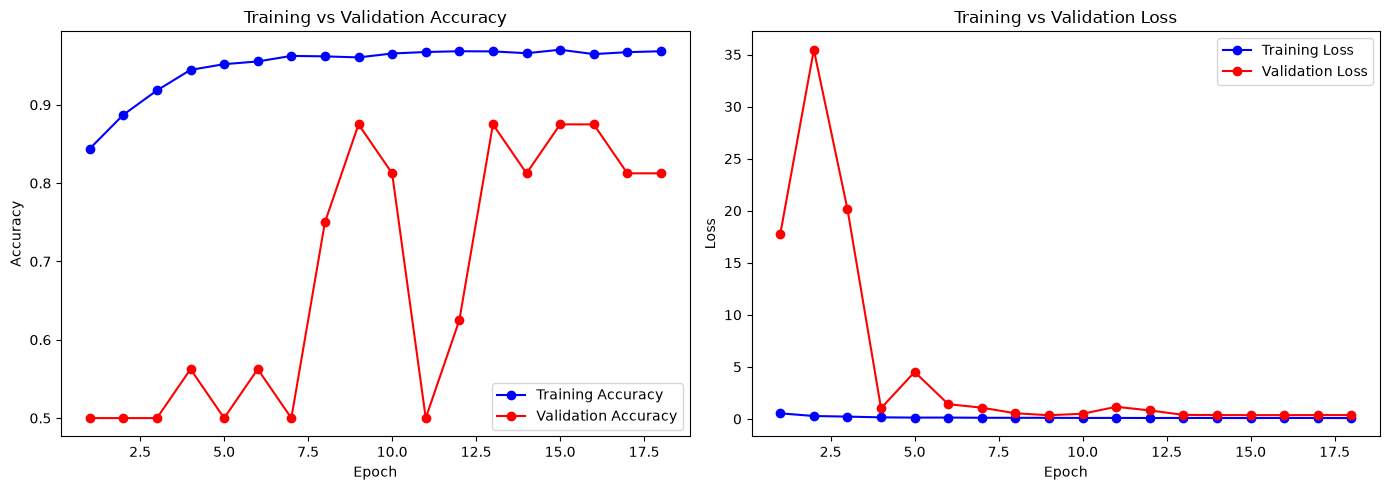

In [18]:
# ==========================================
# Step 13: Plot Training & Validation Curves
# ==========================================

import matplotlib.pyplot as plt

epochs = range(1, len(history.history['accuracy']) + 1)

plt.figure(figsize=(14, 5))

# Accuracy Graph
plt.subplot(1, 2, 1)
plt.plot(epochs, history.history['accuracy'], 'bo-', label='Training Accuracy')
plt.plot(epochs, history.history['val_accuracy'], 'ro-', label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss Graph
plt.subplot(1, 2, 2)
plt.plot(epochs, history.history['loss'], 'bo-', label='Training Loss')
plt.plot(epochs, history.history['val_loss'], 'ro-', label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [19]:
# ==========================================
# Step 14: Make Predictions and Generate Classification Report
# ==========================================

# Predict on test dataset
predictions = model.predict(x_test, verbose=1)
predictions = (predictions > 0.5).astype(np.int32).flatten()

print("First 15 Predictions:")
print(predictions[:15])

# Classification Report
print("\nClassification Report:\n")
print(classification_report(
    y_test,
    predictions,
    target_names=['Pneumonia', 'Normal']
))

20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 122ms/step
First 15 Predictions:
[0 0 0 0 0 0 0 0 1 0 0 0 0 0 0]

Classification Report:

              precision    recall  f1-score   support

   Pneumonia       0.94      0.88      0.91       390
      Normal       0.82      0.91      0.86       234

    accuracy                           0.89       624
   macro avg       0.88      0.90      0.89       624
weighted avg       0.90      0.89      0.89       624



In [20]:
# ==========================================
# Step 16: Confusion Matrix
# ==========================================

cm = confusion_matrix(y_test, predictions)
print(cm)

[[342  48]
 [ 20 214]]


In [21]:
# ==========================================
# Step 17: Identify Correct & Incorrect Predictions
# ==========================================

correct = np.where(predictions == y_test)[0]
incorrect = np.where(predictions != y_test)[0]

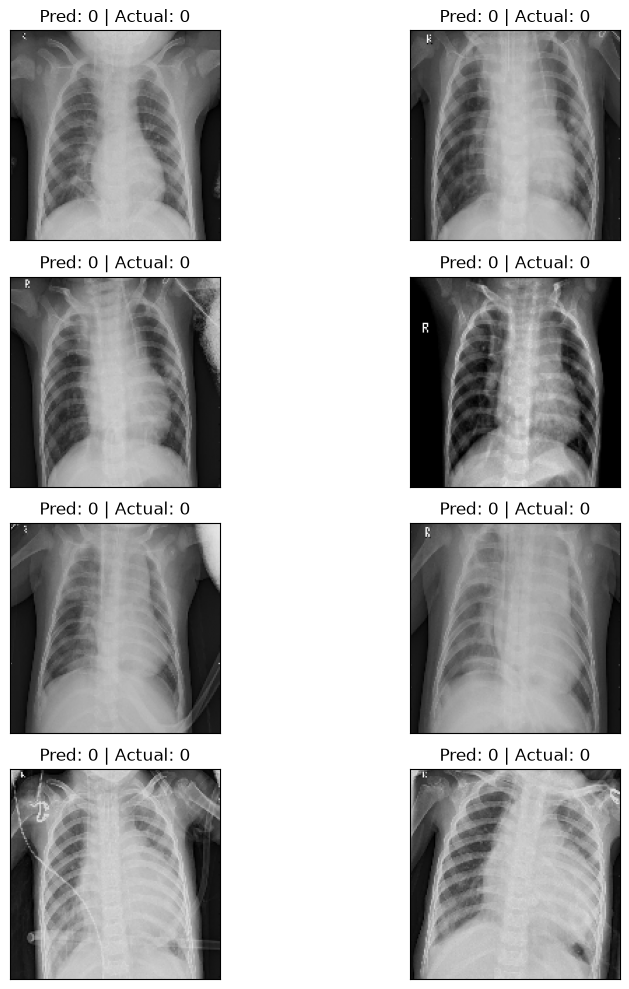

In [22]:
# ==========================================
# Step 18: Visualize Correct Predictions
# ==========================================

plt.figure(figsize=(10, 10))

i = 0
for c in correct[10:18]:

    plt.subplot(4, 2, i + 1)
    plt.xticks([])
    plt.yticks([])

    plt.imshow(x_test[c].reshape(150, 150), cmap='gray')
    
    plt.title(f"Pred: {predictions[c]} | Actual: {y_test[c]}")

    i += 1

plt.tight_layout()
plt.show()

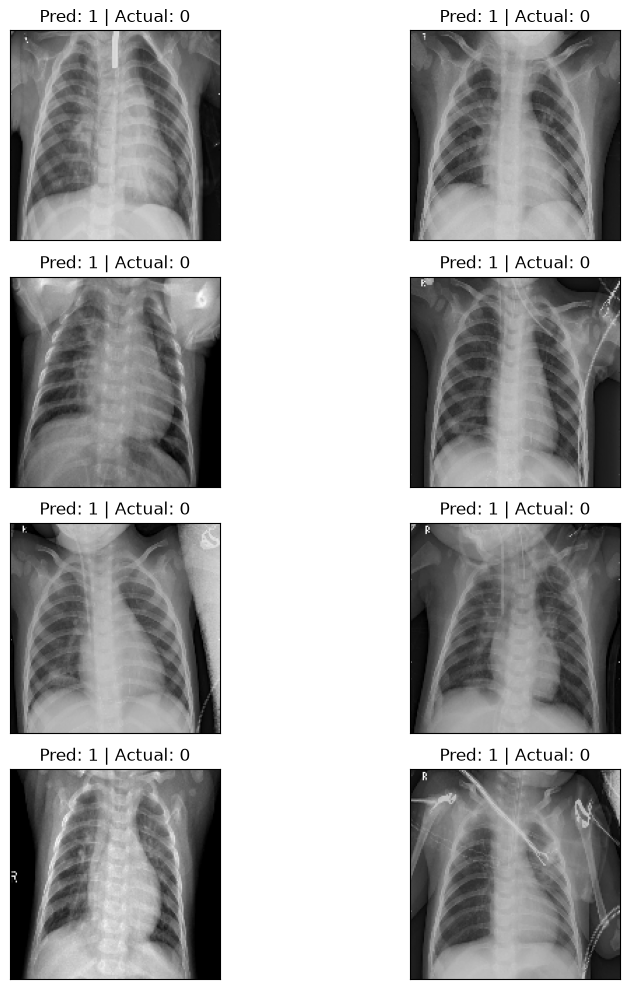

In [23]:
# ==========================================
# Step 19: Visualize Incorrect Predictions
# ==========================================

plt.figure(figsize=(10, 10))

i = 0
for c in incorrect[10:18]:

    plt.subplot(4, 2, i + 1)
    plt.xticks([])
    plt.yticks([])

    plt.imshow(x_test[c].reshape(150, 150), cmap='gray')

    plt.title(f"Pred: {predictions[c]} | Actual: {y_test[c]}")

    i += 1

plt.tight_layout()
plt.show()

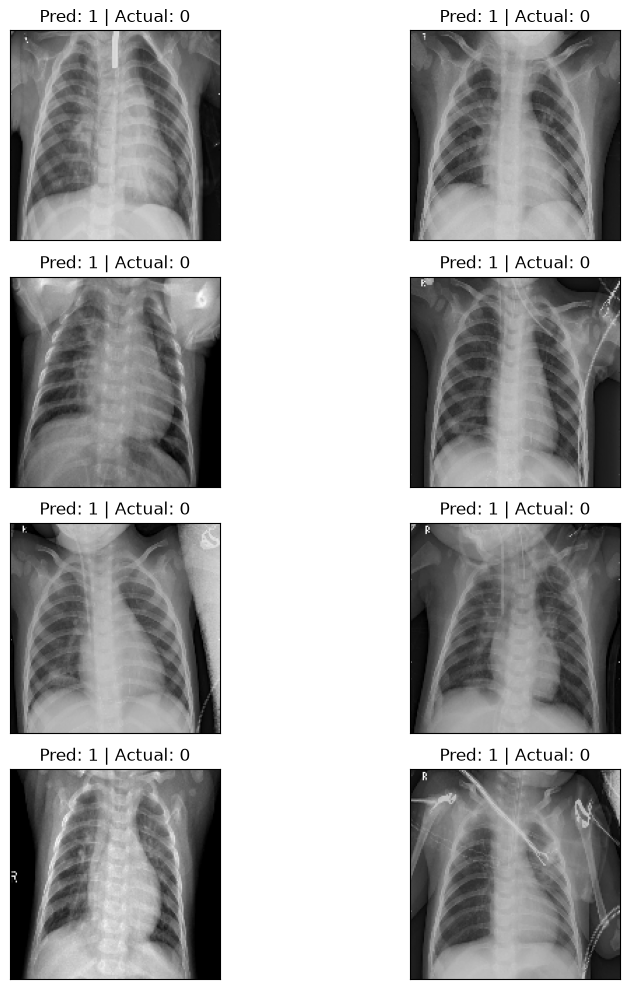

In [24]:
correct = np.where(predictions == y_test)[0]
incorrect = np.where(predictions != y_test)[0]

i = 0
plt.figure(figsize=(10,10))

for c in incorrect[10:18]:

    plt.subplot(4,2,i+1)
    plt.xticks([])
    plt.yticks([])

    plt.imshow(x_test[c].reshape(150,150), cmap='gray')

    plt.title(f"Pred: {predictions[c]} | Actual: {y_test[c]}")

    i += 1

plt.tight_layout()
plt.show()